In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tb = pd.read_csv('BaseFeminicidioEvolucaoMensalCisp.csv', sep = ';', encoding="UTF-8")

#Filtra a tabela para que começe a partir de 2023 e menor que 2026
filtroAno23 = (tb['Ano'] > 2022) & (tb['Ano'] < 2026)
tbFiltrado23 = tb[filtroAno23]

#Filtro para focar só nas Regiôes da Grande Niterói e Região dos Lagos(AISP = 4)
#Tabela filtrada
filtroNit23 = ((tb['Ano'] > 2022) & (tb['Ano'] < 2026)) & (tb['RISP'] == 4)
tbNit23 = tb[filtroNit23]

FemNit23 = tbNit23['Feminic�dio'].sum()
TentNit23 = tbNit23['Tentativa de feminic�dio'].sum()

#pd.to_numeric PEGA A COLUNA 'ANO' E TRANSFORMA EM INTEIRO
#np.array TRANSFORMA ESSES NUMEROS NUM ARRAY E REMOVE OS NUMEROS DUPLICADOS
Anos23 = pd.to_numeric(tb['Ano'], errors='coerce')
Anos23 = np.array(Anos23.drop_duplicates()).flatten()
Anos23 = Anos23[(Anos23 > 2022) & (Anos23 < 2026)]

#Variaveis para somar e salvar os Feminicidios e as Tentaticas por Ano
TotalFemPAno23 = []
TotalTentaPAno23 = []

#Loop para separar cada Ano e somar os dados
for i in range(Anos23.size):
  TotalFemPAno23.append([tbFiltrado23.loc[tbFiltrado23['Ano'] == Anos23[i], 'Feminic�dio'].sum()])
  TotalTentaPAno23.append([tbFiltrado23.loc[tbFiltrado23['Ano'] == Anos23[i], 'Tentativa de feminic�dio'].sum()])

TotalFemPAno23 = np.array(TotalFemPAno23).flatten()
TotalTentaPAno23 = np.array(TotalTentaPAno23).flatten()



Média: 103.66666666666667
Desvio padrão: 3.39934634239519
Outliers:  [[1.37281295 0.98058068 0.39223227]]
Feminicidios registrados nos anos de 2025 : 105
Feminicidios registrados nos anos de 2024 : 107
Feminicidios registrados nos anos de 2023 : 99
Feminicidios registrados em Niterói e Região dos lagos (2023-2026): 45


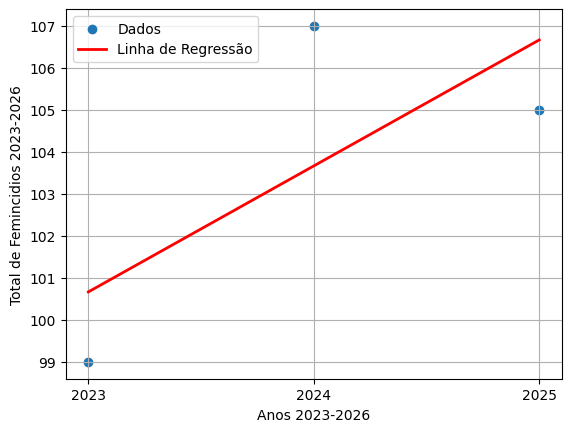

In [53]:
#USANDO O NUMPY PARA CALCULAR O INTERCEPTO E COEFICIENTE ANGULAR
#Variaveis para salvar o coeficiente angular e o intercepto
#np.polyfit() calcula o coeficiente angular e o intercepto
#O 1 é para calcular uma reta
cAngularFemin23, interFemin23 = np.polyfit(Anos23, TotalFemPAno23, 1)
# Intercepto = Onde a reta Cruza o eixo Y
# Coeficiente Angular = o quanto 𝒚 aumenta quando 𝒙 aumenta 1 unidade

#CALCULANDO O PREVISTO
FeminPred2023 = cAngularFemin23 * Anos23 + interFemin23

#FAZENDO O GRÁFICO DA REGRESSÃO LINEAR
#Cria o gráfico
#Passa o x(Anos23), y(TotalFemPAno23) como argumentos
#Cria uma caixa textual e põe o texto "Dados"
plt.scatter(Anos23, TotalFemPAno23, label = 'Dados')

#Cria a linha de regressão, define cor e largura
#Pôe o texto "Linha de Regressão" na caixa
#Passa o x(Anos23), previsto(FeminPred2023) como argumentos
plt.plot(Anos23, FeminPred2023, color = 'red', linewidth = 2, label = 'Linha de Regressão')

#ESSA FUNÇÃO REMOVE OS NÚMEROS QUEBRADOS NO EIXO X
#Define que o eixo X pule de 1 em 1 número
plt.xticks(np.arange(min(Anos23), max(Anos23)+1, 1.0))

plt.xlabel('Anos 2023-2025')
plt.ylabel('Total de Femincidios 2023-2025')
plt.legend()
plt.grid(True)


#VARIAVEL PARA ARMAZENAR A MEDIA
#np.mean() calcula a media da lista
mediaF23 = np.mean(TotalFemPAno23)
print('Média:', mediaF23)


#VARIAVEL PARA ARMAZENAR O DEVIO PADRÃO
#np.std() É UMA FUNÇÃO PARA CALCULAR O DESVIO PADRÃO
#Se calcula o desvio-padrão fazendo, a raiz quadrada da somatória da diferença entre cada um dos
#elementos do conjunto com a média, dividido pela quantidade de elementos do conjunto.
d_padraoFem23 = np.std(TotalFemPAno23)
print('Desvio padrão:', d_padraoFem23)


#VARIAVEL PARA ARMAZENAR O OUTLIER
#np.abs calcula o número absoluto de qualquer variável, nesse caso a lista
#np.mean calcula a media de uma lista
#Nesse caso os números da lista são subtraídos individualmente pela média
#E divide cada resultado
outlierF23 = np.abs((TotalFemPAno23 - mediaF23) / d_padraoFem23)

#np.flip para inverter a ordem dos resultados para ficar condizente com a progressão dos anos
outlierF23 = np.flip(outlierF23)
#.reshape() para remover as quebras de linhas
print("Outliers: ", outlierF23.reshape(1, -1))


for i in range(Anos23.size):
  print('Feminicidios registrados nos anos de',Anos23[i], ':', TotalFemPAno23[i])

print('Feminicidios registrados em Niterói e Região dos lagos (2023-2026):', FemNit23)





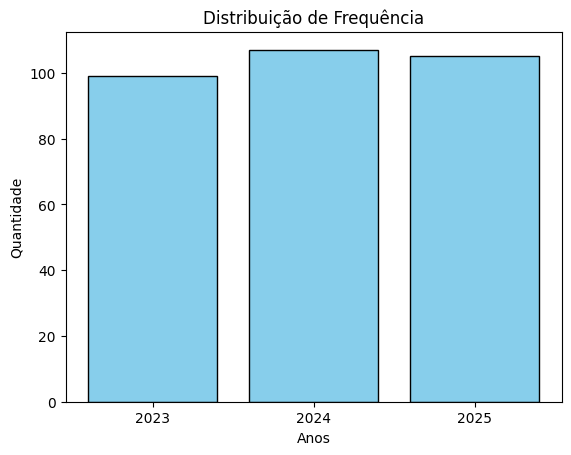

In [45]:
plt.bar(Anos23, TotalFemPAno23, width = 0.8, color='skyblue', edgecolor='black')
plt.xticks(np.arange(min(Anos23), max(Anos23)+1, 1.0))

plt.title('Distribuição de Frequência')
plt.xlabel('Anos')
plt.ylabel('Quantidade')


plt.show()

Média: 332.3333333333333
Desvio padrão: 35.122009560324926
Outliers:  [[0.69282292 1.41411802 0.7212951 ]]
Tentativas registradas no ano de 2025 : 307
Tentativas registradas no ano de 2024 : 382
Tentativas registradas no ano de 2023 : 308
Tentativas registrados em Niterói e Região dos lagos (2023-2026): 159


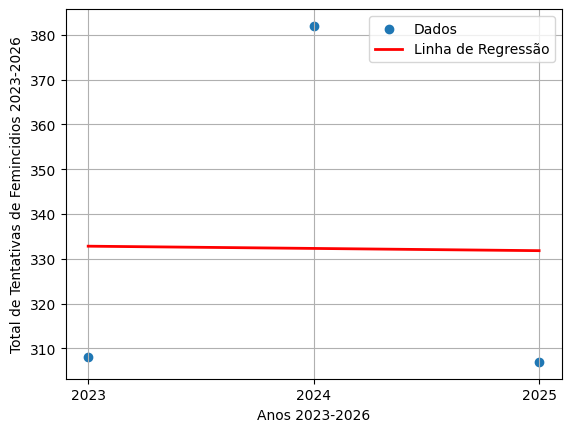

In [56]:
#REGRESSÃO LINEAR TENTATIVA


cAngularTenta23, interTenta23 = np.polyfit(Anos23, TotalTentaPAno23, 1)

TentaPred2023 = cAngularTenta23 * Anos23 + interTenta23

plt.scatter(Anos23, TotalTentaPAno23, label = 'Dados')
plt.plot(Anos23, TentaPred2023, color = 'red', linewidth = 2, label = 'Linha de Regressão')

#ESSA FUNÇÃO REMOVE OS NÚMEROS QUEBRADOS NO EIXO X, POR EXEMPLO, ANTES HAVIA 2025.5
plt.xticks(np.arange(min(Anos23), max(Anos23)+1, 1.0))

plt.xlabel('Anos 2023-2026')
plt.ylabel('Total de Tentativas de Femincidios 2023-2026')
plt.legend()
plt.grid(True)

#VARIAVEL PARA ARMAZENAR A MEDIA
#np.mean() calcula a media da lista
mediaT23 = np.mean(TotalTentaPAno23)
print('Média:', mediaT23)


d_padraoTen23 = np.std(TotalTentaPAno23)
print('Desvio padrão:', d_padraoTen23)


outlierT23 = np.abs((TotalTentaPAno23 - np.mean(TotalTentaPAno23)) / d_padraoTen23)
outlierT23 = np.flip(outlierT23)
print("Outliers: ", outlierT23.reshape(1, -1))



for i in range(Anos23.size):
  print('Tentativas registradas no ano de',Anos23[i], ':', TotalTentaPAno23[i])

print('Tentativas registrados em Niterói e Região dos lagos (2023-2026):', TentNit23)

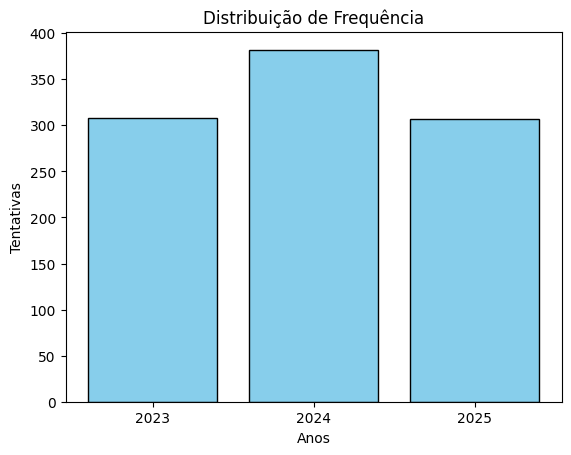

In [49]:
plt.bar(Anos23, TotalTentaPAno23, width = 0.8, color='skyblue', edgecolor='black')
plt.xticks(np.arange(min(Anos23), max(Anos23)+1, 1.0))

plt.title('Distribuição de Frequência')
plt.xlabel('Anos')
plt.ylabel('Tentativas')


plt.show()

In [61]:
#2017 à 2019
#Criado outra tabela para filtrar a tabela salvando apenas os anos a partir de 2019 no mês 2
filtroAno17 = (tb['Ano'] > 2016) & (tb['Ano'] < 2020)
tbFiltrado17 = tb[filtroAno17]

Anos17 = pd.to_numeric(tb['Ano'], errors='coerce')
Anos17 = np.array(Anos17.drop_duplicates()).flatten()
Anos17 = Anos17[(Anos17 < 2020) & (Anos17 > 2016)]

filtroNit17 = ((tb['Ano'] < 2019) | ((tb['Ano'] == 2019) )) & (tb['RISP'] == 4)
tbNit17 = tb[filtroNit17]

FemNit17 = tbNit17['Feminic�dio'].sum()
TentNit17 = tbNit17['Tentativa de feminic�dio'].sum()

TotalFemPAno17 = []
TotalTentaPAno17 = []

#Loop para separar cada Ano e somar os dados
for i in range(Anos17.size):
  TotalFemPAno17.append([tbFiltrado17.loc[tbFiltrado17['Ano'] == Anos17[i], 'Feminic�dio'].sum()])
  TotalTentaPAno17.append([tbFiltrado17.loc[tbFiltrado17['Ano'] == Anos17[i], 'Tentativa de feminic�dio'].sum()])

TotalFemPAno17 = np.array(TotalFemPAno17).flatten()
TotalTentaPAno17 = np.array(TotalTentaPAno17).flatten()



Média: 74.66666666666667
Desvio padrão: 7.408703590297623
Outliers:  [[0.89984254 0.4949134  1.39475594]]
Feminicidios registrados nos anos de 2019 : 85
Feminicidios registrados nos anos de 2018 : 71
Feminicidios registrados nos anos de 2017 : 68
Feminicidios registrados em Niterói e Regiãos dos lagos (2017-2019): 38


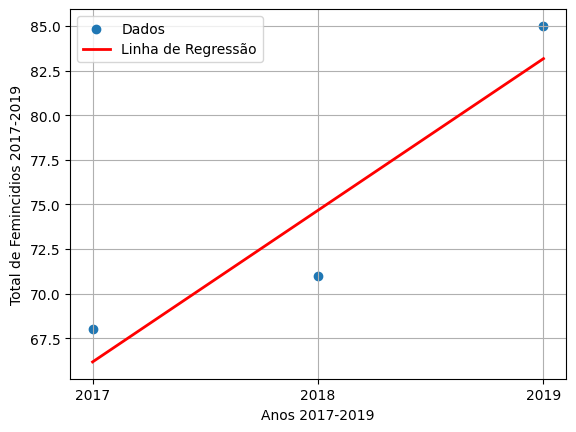

In [62]:
cAngularFemin17, interFemin17 = np.polyfit(Anos17, TotalFemPAno17, 1)

FeminPred17 = cAngularFemin17 * Anos17 + interFemin17

plt.scatter(Anos17, TotalFemPAno17, label = 'Dados')
plt.plot(Anos17, FeminPred17, color = 'red', linewidth = 2, label = 'Linha de Regressão')

plt.xticks(np.arange(min(Anos17), max(Anos17)+1, 1.0))
plt.xlabel('Anos 2017-2019')
plt.ylabel('Total de Femincidios 2017-2019')
plt.legend()
plt.grid(True)


mediaF17 = np.mean(TotalFemPAno17)
print('Média:', mediaF17)


d_padraoFem17 = np.std(TotalFemPAno17)
print('Desvio padrão:', d_padraoFem17)


outlierF17 = np.abs((TotalFemPAno17 - np.mean(TotalFemPAno17)) / d_padraoFem17)
outlierF17 = np.flip(outlierF17)
print("Outliers: ", outlierF17.reshape(1, -1))

for i in range(Anos17.size):
  print('Feminicidios registrados nos anos de',Anos17[i], ':', TotalFemPAno17[i])

print('Feminicidios registrados em Niterói e Regiãos dos lagos (2017-2019):', FemNit17)

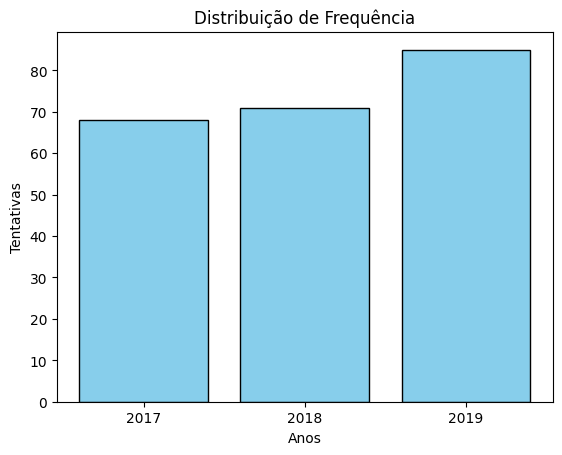

In [66]:
plt.bar(Anos17, TotalFemPAno17, width = 0.8, color='skyblue', edgecolor='black')
plt.xticks(np.arange(min(Anos17), max(Anos17)+1, 1.0))

plt.title('Distribuição de Frequência')
plt.xlabel('Anos')
plt.ylabel('Tentativas')


plt.show()

Média: 290.0
Desvio padrão: 35.13782387494517
Outliers:  [[1.19529314 0.05691872 1.25221187]]
Tentativas de feminicidios registrados nos anos de 2019 : 334
Tentativas de feminicidios registrados nos anos de 2018 : 288
Tentativas de feminicidios registrados nos anos de 2017 : 248
Tentativas de feminicidios registrados em Niterói e Regiãos dos lagos (2017-2019): 149


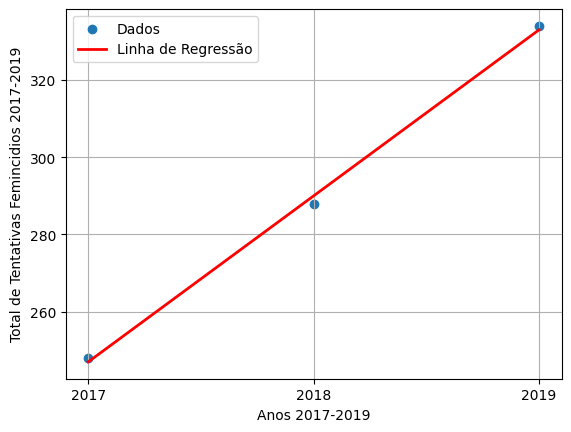

In [63]:
cAngularTenta17, interTenta17 = np.polyfit(Anos17, TotalTentaPAno17, 1)

TentaPred17 = cAngularTenta17 * Anos17 + interTenta17

plt.scatter(Anos17, TotalTentaPAno17, label = 'Dados')
plt.plot(Anos17, TentaPred17, color = 'red', linewidth = 2, label = 'Linha de Regressão')

plt.xticks(np.arange(min(Anos17), max(Anos17)+1, 1.0))

plt.xlabel('Anos 2017-2019')
plt.ylabel('Total de Tentativas Femincidios 2017-2019')
plt.legend()
plt.grid(True)

mediaT17 = np.mean(TotalTentaPAno17)
print('Média:', mediaT17)


d_padraoTen17 = np.std(TotalTentaPAno17)
print('Desvio padrão:', d_padraoTen17)


outlierT17 = np.abs((TotalTentaPAno17 - np.mean(TotalTentaPAno17)) / d_padraoTen17)
outlierT17 = np.flip(outlierT17)
print("Outliers: ", outlierT17.reshape(1, -1))


for i in range(Anos17.size):
  print('Tentativas de feminicidios registrados nos anos de',Anos17[i], ':', TotalTentaPAno17[i])

print('Tentativas de feminicidios registrados em Niterói e Regiãos dos lagos (2017-2019):', TentNit17)

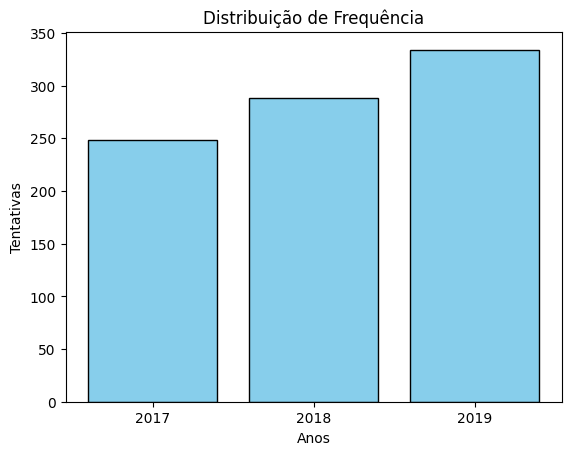

In [67]:
plt.bar(Anos17, TotalTentaPAno17, width = 0.8, color='skyblue', edgecolor='black')
plt.xticks(np.arange(min(Anos17), max(Anos17)+1, 1.0))

plt.title('Distribuição de Frequência')
plt.xlabel('Anos')
plt.ylabel('Tentativas')


plt.show()